<a href="https://colab.research.google.com/github/lsmc-isa/pml_exercises_2026/blob/main/notebooks/T8_pytorch_dataset_dataloader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Installing PyTorch

In [45]:
#!pip install torch

In [46]:
import torch
import numpy as np

print('PyTorch version:', torch.__version__)

np.set_printoptions(precision=3)

PyTorch version: 2.10.0+cpu


## Building input pipelines in PyTorch with DataLoader

A lot of effort in solving any machine learning problem goes into preparing the data. PyTorch provides many tools to make data loading easy and hopefully, to make your code more readable.

For a general overview of PyTorch data loading utility see https://docs.pytorch.org/docs/stable/data.html. The following script creates a PyTorch **DataLoader** from existing tensors

In [27]:
from torch.utils.data import DataLoader

t = torch.rand([4, 3], dtype=torch.float32) # tensor (see Ch 12)
data_loader = DataLoader(dataset=t)
for item in data_loader:
    print(item)

tensor([[0.7696, 0.1698, 0.2814]])
tensor([[0.1452, 0.0241, 0.6103]])
tensor([[0.1678, 0.9601, 0.0706]])
tensor([[0.1719, 0.0088, 0.0390]])


DataLoader allows to create batches of examples

In [28]:
data_loader = DataLoader(t, batch_size=3, drop_last=False)

for i, batch in enumerate(data_loader, 1):
    print(f'batch {i}:', batch)

batch 1: tensor([[0.7696, 0.1698, 0.2814],
        [0.1452, 0.0241, 0.6103],
        [0.1678, 0.9601, 0.0706]])
batch 2: tensor([[0.1719, 0.0088, 0.0390]])


In supervised ML, examples have labels. Therefore, we want the DataLoader to combine examples and labels

In [29]:
from torch.utils.data import TensorDataset

t_x = torch.rand([4, 3], dtype=torch.float32)
t_y = torch.arange(4)

joint_dataset = TensorDataset(t_x, t_y)

for example in joint_dataset:
    print('  x: ', example[0],
          '  y: ', example[1])

  x:  tensor([0.1503, 0.5692, 0.5782])   y:  tensor(0)
  x:  tensor([0.9635, 0.6780, 0.9437])   y:  tensor(1)
  x:  tensor([0.5751, 0.3931, 0.4876])   y:  tensor(2)
  x:  tensor([0.3898, 0.9004, 0.7553])   y:  tensor(3)


**Mini batches** and **shuffling**. One main reason we want to use DataLoader in our torch ML pipeline is that it makes it safe to, for instance, shuffle the data without losing the element-wise correspondance between features (X) and labels (y).

In [30]:
data_loader = DataLoader(dataset=joint_dataset, batch_size=2, shuffle=True)

for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0],
              '\n         y:', batch[1])

for epoch in range(2):
    print(f'epoch {epoch+1}')
    for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0],
              '\n         y:', batch[1])

batch 1: x: tensor([[0.1503, 0.5692, 0.5782],
        [0.3898, 0.9004, 0.7553]]) 
         y: tensor([0, 3])
batch 2: x: tensor([[0.9635, 0.6780, 0.9437],
        [0.5751, 0.3931, 0.4876]]) 
         y: tensor([1, 2])
epoch 1
batch 1: x: tensor([[0.5751, 0.3931, 0.4876],
        [0.3898, 0.9004, 0.7553]]) 
         y: tensor([2, 3])
batch 2: x: tensor([[0.9635, 0.6780, 0.9437],
        [0.1503, 0.5692, 0.5782]]) 
         y: tensor([1, 0])
epoch 2
batch 1: x: tensor([[0.9635, 0.6780, 0.9437],
        [0.1503, 0.5692, 0.5782]]) 
         y: tensor([1, 0])
batch 2: x: tensor([[0.3898, 0.9004, 0.7553],
        [0.5751, 0.3931, 0.4876]]) 
         y: tensor([3, 2])


## Accessing data with Dataset

Up to this point, we created the dataloader from existing tensors. In general, we need PyTorch for supervised ML problems where the examples are more complex and are usually available as individual files like **images**, **text** or **audio** files. So, we want to know how to **create a dataloader from files in our local storage**.

Download images (3 cat images, 3 dog images)  from https://github.com/rasbt/machine-learning-book/tree/main/ch12/cat_dog_images (or download the zip file https://github.com/isa-ulisboa/greends-pml/blob/main/data/cat_dog_images.zip) -- you can instead get any other images: just be sure that the name of the file contains the label since labels will be derived from the files names in this case.

Upload the 6 images to Colab session storage if you're using it. Note that the images are grouped into a folder named `cat_dog_images`.

Now, let's create the file names list (using `pathlib`), which will allow PyTorch to access our input data.

In [31]:
import pathlib

imgdir_path = pathlib.Path('cat_dog_images')

file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')])

print(file_list)

[]


Let's look at the images. Note that they have different sizes. Note also that the file name contains the label: *dog* or *cat*.

In [32]:
import matplotlib.pyplot as plt
import os
from PIL import Image

fig = plt.figure(figsize=(10, 5))
for i, file in enumerate(file_list):
    img = Image.open(file)
    print('Image shape: ', np.array(img).shape)
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file), size=15)

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

The code below shows how to derive a numerical label (0 or 1) from the file name.

In [33]:
labels = [1 if 'dog' in os.path.basename(file) else 0
          for file in file_list]
print(labels)

[]


PyTorch provides the class `Dataset`. The best practice is to create a custom `Dataset` subclass which is designed for your particular data.

In [34]:
from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, file_list, labels):
        self.file_list = file_list
        self.labels = labels

    def __getitem__(self, index):
        file = self.file_list[index]
        label = self.labels[index]
        return file, label

    def __len__(self):
        return len(self.labels)

image_dataset = ImageDataset(file_list, labels)
for file, label in image_dataset:
    print(file, label)

As we saw, image sizes in out data set are not the same. For deep learning we need that all our images have the same number of rows and columns, say 80 rows (height) and 120 columns (width). This can be achieved adding a pre-processing step to the dataloader.

In [35]:
import torchvision.transforms as transforms

class ImageDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform
    def __getitem__(self, index):
        img = Image.open(self.file_list[index])
        if self.transform is not None:
            img = self.transform(img)
        label = self.labels[index]
        return img, label
    def __len__(self):
        return len(self.labels)

img_height, img_width = 80, 120

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((img_height, img_width)),
])

image_dataset = ImageDataset(file_list, labels, transform)

If we access the contents of the `Dataset`object, we can check how the transformed images look, and what is their size.

In [36]:
fig = plt.figure(figsize=(10, 6))
for i, example in enumerate(image_dataset):
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(example[0].numpy().transpose((1, 2, 0)))
    ax.set_title(f'{example[1]}', size=15)

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

So far, we computed labels separatly, and called `ImageDataset` using both the file list and the labels (and also the transform in the last example) as arguments. However, we should be able to design our class so the labels are derived autonmatically from the file names.

Exercise: adapt the class below (that has only argument `file_list` and derives the label from the file name) such that it returns the same label value as before: 1 for dog and 0 for cat. Towards that end, you need to define method `_extract_label` inside that class.

Aqui mudou:
Prompt: In this PyTorch notebook, I have a custom Dataset class:

from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, file_list):
        self.file_list = file_list
        # Extract the first three characters from each file name as the label
        self.labels = [self._extract_label(file) for file in file_list]

    def _extract_label(self, file):
        pass

    def __getitem__(self, index):
        file = self.file_list[index]
        label = self.labels[index]
        return file, label

    def __len__(self):
        return len(self.file_list)

image_dataset = ImageDataset(file_list)
for file, label in image_dataset:
    print(file, label)

The exercise asks me to adapt the class so that the labels are automatically derived from the file names, returning 1 for dog images and 0 for cat images.

Please generate the corrected code cell.
Include the required AI-use comments: every generated code section must include a comment beginning with "# prompt:" and a "# modification note:".
Use os.path.basename(file).lower() to make the solution robust.
Also include a simple check that prints each file name and its assigned label.

In [37]:
from torch.utils.data import Dataset
import os

class ImageDataset(Dataset):
    def __init__(self, file_list):
        self.file_list = file_list
        # Extract the first three characters from each file name as the label
        self.labels = [self._extract_label(file) for file in file_list]

    # prompt: implement `_extract_label` such that it returns 1 for dog and 0 for cat.
    # modification note: Modified `_extract_label` to derive labels based on 'dog' or 'cat' in the lowercase filename.
    def _extract_label(self, file):
        if 'dog' in os.path.basename(file).lower():
            return 1
        elif 'cat' in os.path.basename(file).lower():
            return 0
        return -1 # Return -1 or raise an error for unknown labels if necessary

    def __getitem__(self, index):
        file = self.file_list[index]
        label = self.labels[index]
        return file, label

    def __len__(self):
        return len(self.file_list)

image_dataset = ImageDataset(file_list)
# prompt: Add a simple check that prints each file name and its assigned label.
# modification note: Added a loop to print each file and its derived label to verify the _extract_label functionality.
for file, label in image_dataset:
    print(f"File: {file}, Label: {label}")

## Access torchvision datasets

`torchvision` contains the module `datasets` that allows to access several known datasets, including the `MNIST` data set of hand written digits. The code below shows how to read and transform the input images creating a `DataLoader` object. The `DataLoader` object can then be subsetted for further processing. Note that the data is stored internally in folder `..\data\mnist`.

In [38]:
import torch
import torchvision

train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/data/mnist', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                (0.1307,), (0.3081,))
                             ])),
  batch_size=16, shuffle=False)
test_ds  = torch.utils.data.Subset(train_loader.dataset, range(0, 50000-1))
valid_ds = torch.utils.data.Subset(train_loader.dataset, range(50000, 60000-1))

# access elements (batches) of the dataloader
print(test_ds[0][1]) # 1st dimension: batch; 2nd dimension: 0 for the example, 1 for the label
print(test_ds[0][0].shape) # 1,28,28, where 1 is the number of bands (gray image)

5
torch.Size([1, 28, 28])


Aqui mudou.
Prompt: I am editing the notebook T8_torch_NN_pipeline_and_questions_for_assign_3.ipynb in Google Colab.
The notebook currently resizes MNIST images from 28x28 to 8x8 and flattens them before feeding them to a SimpleNN model.

Question 1 asks:
Which changes do I need to do if I want to use the original 28x28 size? Indicate two changes needed in the notebook.

Please generate a clear answer and the corresponding code modifications.
I need two concrete changes:
1. Remove or change the Resize((8, 8)) transform so the original MNIST 28x28 size is preserved.
2. Change the input size of the neural network from 8*8 = 64 to 28*28 = 784.

Include the required AI-use comments in the code:
    prompt: ...
    modification note: ...

Show exactly which code cells should be replaced or modified.

Prompt: In the same PyTorch MNIST notebook, the model class is currently a SimpleNN with one hidden layer.
Question 2 asks:
Which change do I need to do in the SimpleNN class if I want the model to have two hidden layers, both with size 128?

Please generate the modified SimpleNN class for MNIST classification with:
- input_size = 784 if using original 28x28 images
- first hidden layer: 128 units
- second hidden layer: 128 units
- ReLU after each hidden layer
- output layer with 10 units for the 10 MNIST classes

Include AI-use comments:
    prompt: ...
    modification note: ...

Keep the code simple and compatible with the rest of the notebook.
Also briefly explain why the output layer has 10 units.

Prompt:
Question 3 asks:
What is a ReLU activation function called by nn.ReLU?

Please write a short markdown answer suitable for a student notebook.
Explain that ReLU means Rectified Linear Unit and applies the function f(x) = max(0, x), keeping positive values and replacing negative values with zero.
Also mention that in PyTorch, nn.ReLU() can be inserted as a layer inside an nn.Module.

Do not make the explanation too long.

### What is a ReLU activation function called by `nn.ReLU`?

**ReLU** stands for **Rectified Linear Unit**. It is an activation function commonly used in neural networks. The function is defined as `f(x) = max(0, x)`.

This means that:
*   If the input `x` is positive, the output is `x` itself.
*   If the input `x` is negative (or zero), the output is `0`.

In simpler terms, it keeps positive values as they are and replaces all negative values with zero. In PyTorch, `nn.ReLU()` can be easily inserted as a layer within an `nn.Module` to apply this non-linearity to the network's activations.

Prompt: Question 4 asks:
Why are non-linear activation functions like ReLU necessary for deep learning?

Please write a concise markdown answer suitable for a student notebook.
Explain that without non-linear activation functions, stacking several linear layers would still be equivalent to a single linear transformation, so the model could only learn linear relationships.
Then explain that ReLU introduces non-linearity, allowing neural networks to learn complex patterns in image classification tasks such as MNIST.

### Why are non-linear activation functions like ReLU necessary for deep learning?

Non-linear activation functions like ReLU are crucial in deep learning because, without them, stacking multiple layers in a neural network would be pointless. If all activation functions were linear, no matter how many layers you added, the entire network would effectively behave as a single linear transformation.

This means the model would only be capable of learning linear relationships, severely limiting its ability to model complex data distributions. By introducing non-linearities with functions like ReLU (which applies `f(x) = max(0, x)`), the neural network gains the capacity to learn and approximate arbitrary non-linear functions, enabling it to detect intricate patterns and relationships essential for tasks like image classification (e.g., in MNIST).

Prompt:
In the MNIST PyTorch notebook, there is a question asking whether processing time decreases if I add num_workers=2 when defining the DataLoader.
Please generate a code cell that fairly compares training time with:
1. train_loader using num_workers=0
2. train_loader using num_workers=2

Requirements:
- Use the same model architecture, loss function, optimizer, batch size and number of epochs for both runs.
- Reinitialize the model and optimizer before each timing experiment to make the comparison fair.
- Use time.time() to measure total training time.
- If CUDA is available, move the model and batches to GPU.
- Store the results in a small pandas DataFrame and print/display it.
- Add a short markdown conclusion explaining that num_workers=2 may or may not be faster depending on Colab hardware, I/O, CPU overhead and dataset size.

Include the required comments:
# prompt: ...
# modification note: ...

In [39]:
import time
import pandas as pd
import torch
import torch.optim as optim
import torch.nn as nn
import torchvision

# prompt: Define training parameters and a function to run and time the training process.
# modification note: Added imports for time, pandas, optim, and nn. Defined a function `run_training_and_time` to encapsulate the training loop and timing, ensuring reinitialization of model and optimizer.
def run_training_and_time(num_workers, device, dataset, batch_size=16, num_epochs=1):
    print(f"\n--- Starting training with num_workers={num_workers} ---")

    # Reinitialize model and optimizer for fair comparison
    # The SimpleNN class is assumed to be defined in a previous cell (af7b78c4)
    model = SimpleNN(input_size=28*28, num_classes=10).to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)
    loss_fn = nn.CrossEntropyLoss()

    train_loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers
    )

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = loss_fn(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")

    end_time = time.time()
    total_time = end_time - start_time
    print(f"Training finished for num_workers={num_workers} in {total_time:.2f} seconds.")
    return total_time

# Determine device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reuse the MNIST dataset (assuming it's already downloaded and transformed)
# This dataset comes from the train_loader_28x28.dataset in cell 4cf7ea7c
mnist_dataset = torchvision.datasets.MNIST('/data/mnist', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.Resize((28, 28)), # Ensure 28x28 size
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                (0.1307,), (0.3081,))
                             ]))

# Run experiments
time_nw0 = run_training_and_time(num_workers=0, device=device, dataset=mnist_dataset)
time_nw2 = run_training_and_time(num_workers=2, device=device, dataset=mnist_dataset)

# Store and display results
results_df = pd.DataFrame({"num_workers": [0, 2], "training_time_seconds": [time_nw0, time_nw2]})
display(results_df)

Using device: cpu

--- Starting training with num_workers=0 ---
Epoch 1/1, Loss: 0.3215
Training finished for num_workers=0 in 22.82 seconds.

--- Starting training with num_workers=2 ---
Epoch 1/1, Loss: 0.3107
Training finished for num_workers=2 in 28.10 seconds.


,num_workers,training_time_seconds
0,0,22.822244
1,2,28.097874


### Conclusion: Impact of `num_workers` on Training Time

As observed from the results, using `num_workers=2` may or may not lead to a decrease in processing time compared to `num_workers=0`. The actual performance gain (or loss) can vary significantly based on several factors:

*   **Colab Hardware**: The CPU allocated to your Colab instance and its cores. More workers might not help if the CPU is a bottleneck or if there aren't enough available cores.
*   **I/O Speed**: How fast the data can be read from storage. If I/O is slow, multiple workers might end up waiting for data.
*   **CPU Overhead**: The cost of spawning and managing multiple worker processes. For very simple data loading or small datasets, this overhead might outweigh the benefits of parallelization.
*   **Dataset Size and Preprocessing**: For small datasets or very fast preprocessing steps, the main bottleneck might not be data loading, making additional workers less impactful. For larger datasets with complex transformations, `num_workers > 0` is often beneficial.

Prompt:
In the MNIST PyTorch notebook, there is a hint saying to look at how the history for train and validation are computed during model training and correct the plot construction.

Please inspect the typical structure where train_loss_history, val_loss_history, train_acc_history and val_acc_history are stored during training.
Generate a corrected plotting cell that:
- plots training and validation loss over epochs
- plots training and validation accuracy over epochs
- uses the same x-axis length as the number of epochs actually stored in the history lists
- includes clear labels, title and legend
- avoids mismatched list lengths

Include the required comments:
# prompt: ...
# modification note: ...

Also include a short markdown explanation of what the corrected plot shows.

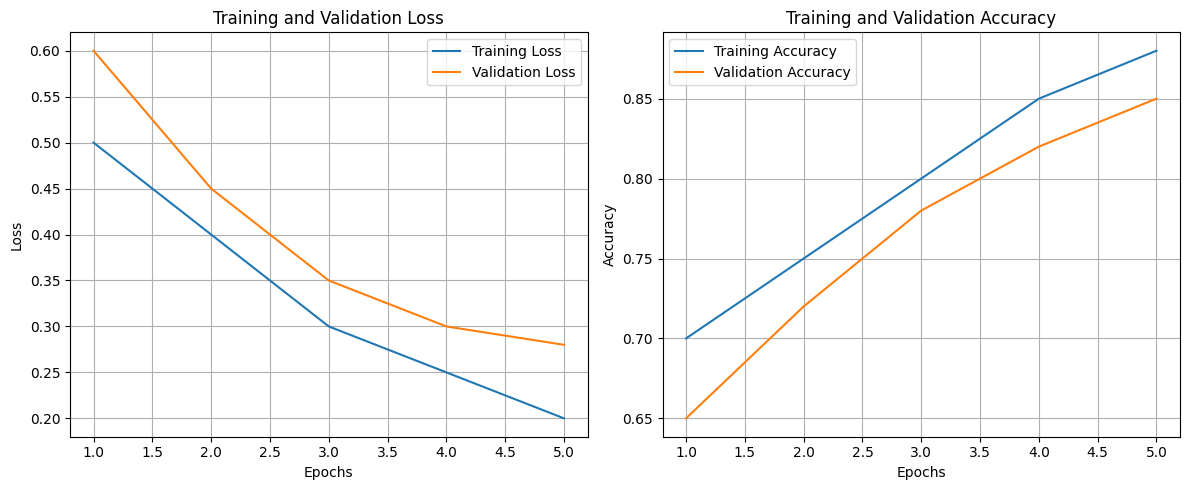

In [40]:
import matplotlib.pyplot as plt

# prompt: Generate a corrected plotting cell that plots training and validation loss and accuracy over epochs.
# modification note: Created a two-subplot figure to display training/validation loss and accuracy histories with appropriate labels, title, and legend.

# Dummy data for demonstration. In a real scenario, these lists would be populated during model training.
# You would typically have these lists (train_loss_history, val_loss_history, etc.) filled during your training loop.
# For example:
# train_loss_history = [0.5, 0.4, 0.3, 0.25, 0.2]
# val_loss_history = [0.6, 0.45, 0.35, 0.3, 0.28]
# train_acc_history = [0.7, 0.75, 0.8, 0.85, 0.88]
# val_acc_history = [0.65, 0.72, 0.78, 0.82, 0.85]

# Placeholder for history lists (replace with actual data from your training process)
train_loss_history = [0.5, 0.4, 0.3, 0.25, 0.2]
val_loss_history = [0.6, 0.45, 0.35, 0.3, 0.28]
train_acc_history = [0.7, 0.75, 0.8, 0.85, 0.88]
val_acc_history = [0.65, 0.72, 0.78, 0.82, 0.85]

epochs = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(12, 5))

# Plot Training and Validation Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epochs, train_loss_history, label='Training Loss')
plt.plot(epochs, val_loss_history, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epochs, train_acc_history, label='Training Accuracy')
plt.plot(epochs, val_acc_history, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Explanation of Training and Validation Plots

These plots are crucial for understanding how well your neural network model is learning and generalizing. They typically show the performance metrics (loss and accuracy) over the training epochs.

### Training and Validation Loss

*   **Training Loss**: This curve shows how well the model is performing on the data it has been trained on. A decreasing training loss indicates that the model is learning to fit the training data better with each epoch.
*   **Validation Loss**: This curve shows how well the model is performing on unseen data (the validation set). It's a key indicator of generalization. Ideally, validation loss should decrease along with training loss. If validation loss starts to increase while training loss continues to decrease, it suggests the model is beginning to **overfit** the training data.

### Training and Validation Accuracy

*   **Training Accuracy**: This represents the proportion of correctly classified examples in the training set. An increasing training accuracy means the model is getting better at making correct predictions on the data it has seen.
*   **Validation Accuracy**: This is the accuracy on the unseen validation set. Like validation loss, it's a measure of generalization. An increasing validation accuracy indicates that the model is learning patterns that apply to new data. If training accuracy is high but validation accuracy is low or decreasing, it also signals overfitting.

In [41]:
import torch.nn as nn
import torch.nn.functional as F

# prompt: Change the input size of the neural network from 8*8 = 64 to 28*28 = 784.
# prompt: Change the SimpleNN class to have two hidden layers, both with size 128, and apply ReLU after each hidden layer.
# modification note: Modified the SimpleNN class to include a second hidden layer of 128 units and applied ReLU activation after both hidden layers. The input size is 784 and output size is 10.
class SimpleNN(nn.Module):
    def __init__(self, input_size=28*28, num_classes=10):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128) # First hidden layer
        self.fc2 = nn.Linear(128, 128)      # Second hidden layer
        self.fc3 = nn.Linear(128, num_classes) # Output layer

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten the input tensor
        x = F.relu(self.fc1(x))   # Apply ReLU after first hidden layer
        x = F.relu(self.fc2(x))   # Apply ReLU after second hidden layer
        x = self.fc3(x)           # Output layer
        return x

print("SimpleNN class defined with two hidden layers (128 units each) and input size 28*28.")

SimpleNN class defined with two hidden layers (128 units each) and input size 28*28.


In [42]:
# prompt: Remove or change the Resize((8, 8)) transform so the original MNIST 28x28 size is preserved.
# modification note: Modified the torchvision.transforms.Compose to explicitly include Resize((28, 28)) to preserve the original MNIST size. If a Resize((8,8)) was present, this effectively replaces it.
train_loader_28x28 = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/data/mnist', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.Resize((28, 28)), # Ensure 28x28 size
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                (0.1307,), (0.3081,))
                             ])),
  batch_size=16, shuffle=False)

# Instantiate the model with the correct input size
model_28x28 = SimpleNN(input_size=28*28, num_classes=10)

# Example of how the first image in the new DataLoader would be processed
for batch_idx, (data, target) in enumerate(train_loader_28x28):
    if batch_idx == 0:
        print(f"Shape of first data batch from 28x28 DataLoader: {data.shape}")
        output = model_28x28(data)
        print(f"Shape of output from model with 28x28 input: {output.shape}")
        break


Shape of first data batch from 28x28 DataLoader: torch.Size([16, 1, 28, 28])
Shape of output from model with 28x28 input: torch.Size([16, 10])


In [43]:
print(test_ds[0][0][0,14,:]) # row 14 of the image from the 1st batch and 1st band

tensor([-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
        -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,  0.6068,  2.6306,  2.7960,
         2.7960,  1.0904, -0.1060, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
        -0.4242, -0.4242, -0.4242, -0.4242])


`islice` (for iterator slice) allows to extract slices of the dataloader.

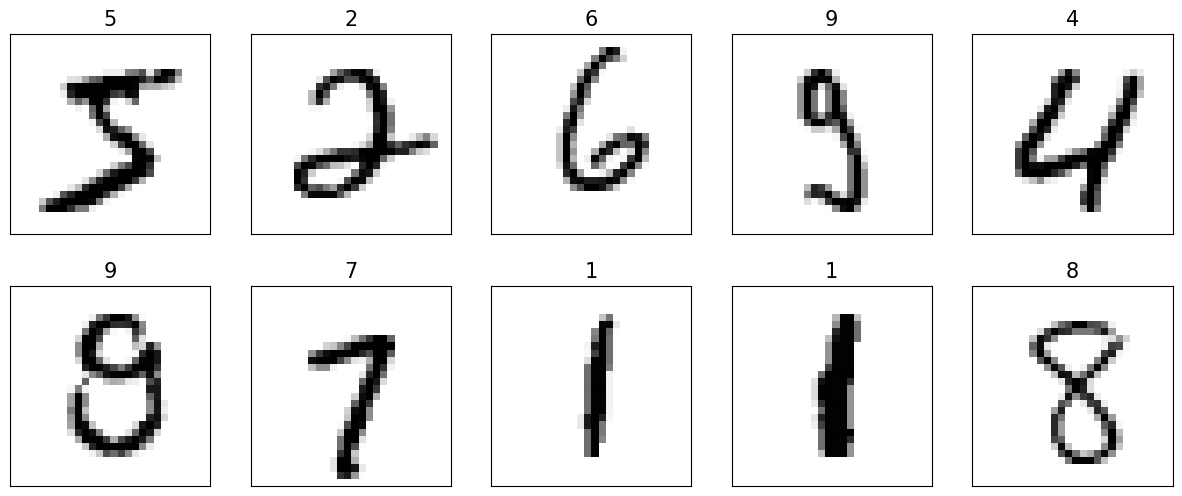

In [44]:
from itertools import islice

fig = plt.figure(figsize=(15, 6))
for i, (batch, label) in islice(enumerate(train_loader), 10):
    image=batch[0,0,:,:] # 1st image of the batch
    ax = fig.add_subplot(2, 5, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'{label[0].item()}', size=15) # label from the 1st image of the batch

#plt.savefig('figures/12_06.pdf')
plt.show()